In [25]:
import numpy as np

In [26]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [27]:
def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1-eps)
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

In [28]:
def leaf_weight(G, H, lam):
    return -G/ (H+lam)

In [29]:
class LeafNode:
    def __init__(self, w):
        self.w = w

class SplitNode:
    def __init__(self, feature, threshold, left, right):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right

In [30]:
def predict_tree(node, X):
    out = np.zeros(X.shape[0])
    for i in range(X.shape[0]):
        cur = node
        while isinstance(cur, SplitNode):
            cur = cur.left if X[i, cur.feature] <= cur.threshold else cur.right
        out[i] = cur.w
    return out


In [31]:
def xgboost_predict(H0, trees, eta, X):
    z = np.full(X.shape[0], H0)
    for tree in trees:
        z = z + eta * predict_tree(tree, X)
    return sigmoid(z)

In [32]:
def build_tree(X, g, h, depth, max_depth, lam, gamma):
    """Greedly grow one regression tree using the XGBoost gain criterion"""
    G, H = g.sum(), h.sum()

    if depth == max_depth or len(g) < 2:
        return LeafNode(w=leaf_weight(G, H, lam))

    best_gain, best_j, best_s = -np.inf, None, None
    n, d = X.shape

    for j in range(d):
        order = np.argsort(X[:, j])
        Xj_sorted = X[order, j]
        g_sorted, h_sorted = g[order], h[order]

        G_l = np.cumsum(g_sorted)
        H_l = np.cumsum(h_sorted)
        Gr = G - G_l
        Hr = H - H_l

        gain  = 0.5 * (G_l**2/(H_l+lam) + Gr**2/(Hr+lam) - G**2/(H+lam)) - gamma

        i_star = np.argmax(gain[:-1])
        if gain[i_star] > best_gain:
            best_gain = gain[i_star]
            best_j = j
            best_s = (Xj_sorted[i_star] + Xj_sorted[i_star+1])/2

    if best_gain <= 0:
        return LeafNode(w=leaf_weight(G, H, lam))

    left_mask = X[:, best_j] < best_s
    right_mask = ~left_mask

    left_child  = build_tree(X[left_mask],  g[left_mask],  h[left_mask],  depth+1, max_depth, lam, gamma)
    right_child = build_tree(X[right_mask], g[right_mask], h[right_mask], depth+1, max_depth, lam, gamma)

    return SplitNode(feature=best_j, threshold=best_s, left=left_child, right=right_child)


In [33]:
def xgboost_classifier_fit(X, y, T, eta, lam, gamma, max_depth):
    """
    X: (n, d) feature matrix
    y: (n,) binary labels in {0, 1}
    T: number of boosting rounds
    eta: learning rate
    lam: L2 regularization on leaf weights (lambda)
    gamma: min gain required to make a split (also per-leaf penalty)
    max_depth: max depth of each tree
    """

    history = {"loss": [], "grad_sum": [], "grad_absmean": [], "hess_mean": []}

    n = X.shape[0]
    p_bar = y.mean()
    H0 = np.log(p_bar/(1 - p_bar))
    z = np.full(n, H0)
    trees = []

    for m in range(T):
        p = sigmoid(z)
        g = p - y
        h = p * (1-p)

        r = -g                                    # pseudo-residual, y - p
        print(f"Round {m}: sum of residuals = {r.sum():.4f}") 

        history["loss"].append(log_loss(y, p))          # needs a log_loss(y, p) helper
        history["grad_sum"].append(g.sum())
        history["grad_absmean"].append(np.abs(g).mean())
        history["hess_mean"].append(h.mean())


        tree = build_tree(X, g, h, depth=0, max_depth=max_depth, lam=lam, gamma=gamma)
        trees.append(tree)

        print(len(trees))

        f_m = predict_tree(tree, X)
        z = z + eta * f_m

    import matplotlib.pyplot as plt
    plt.plot(history["loss"])
    plt.xlabel("Boosting round"); plt.ylabel("Log-loss"); plt.show()

    return H0, trees, eta


In [34]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

def make_dataset(n=200, d=2):
    """
    Two overlapping Gaussian blobs -> a binary classification problem
    that isn't perfectly separable (so boosting actually has work to do).
    """
    n0 = n // 2
    n1 = n - n0
    n2 = n - n1

    # Class 0: centered near (-1, -1)
    X0 = np.random.randn(n0, d) * 1.2 + np.array([-1, -1, -1, -1])
    y0 = np.zeros(n0)

    # Class 1: centered near (2, 2)
    X1 = np.random.randn(n1, d) * 1.2 + np.array([2, 2, 2, 2])
    y1 = np.ones(n1)

    # # Class 1: centered near (2, 2)
    # X2 = np.random.randn(n2, d) * 1.2 + np.array([5, 5, 5, 5])
    # y2 = np.ones(n2)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    # shuffle
    idx = np.random.permutation(n)
    return X[idx], y[idx]

X, y = make_dataset(n=1000, d=4)

# print(X[0][1])

# simple train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(X_train.shape, y_train.shape)   # (160, 2) (160,)
print(X_test.shape,  y_test.shape)    # (40, 2) (40,)
print("class balance (train):", y_train.mean())

(700, 4) (700,)
(300, 4) (300,)
class balance (train): 0.49714285714285716


Round 0: sum of residuals = 0.0000
1
Round 1: sum of residuals = -0.7737
2
Round 2: sum of residuals = -0.7141
3
Round 3: sum of residuals = -0.5775
4
Round 4: sum of residuals = -0.3237
5
Round 5: sum of residuals = -0.4549
6
Round 6: sum of residuals = -0.6044
7
Round 7: sum of residuals = -0.5767
8
Round 8: sum of residuals = -0.4588
9
Round 9: sum of residuals = -0.5190
10
Round 10: sum of residuals = -0.2514
11
Round 11: sum of residuals = -0.0836
12
Round 12: sum of residuals = -0.1353
13
Round 13: sum of residuals = -0.2375
14
Round 14: sum of residuals = -0.2302
15
Round 15: sum of residuals = -0.2852
16
Round 16: sum of residuals = -0.3085
17
Round 17: sum of residuals = -0.2795
18
Round 18: sum of residuals = -0.3065
19
Round 19: sum of residuals = -0.2478
20


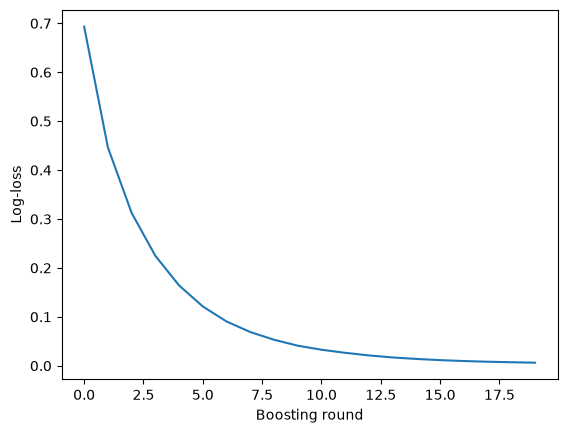

test accuracy: 0.9766666666666667


In [35]:
H0, trees, eta= xgboost_classifier_fit(
    X_train, y_train,
    T=20, eta=0.3, lam=1.0, gamma=0.0, max_depth=4
)

p_test = xgboost_predict(H0, trees, eta, X_test)
y_pred = (p_test > 0.5).astype(int)

accuracy = (y_pred == y_test).mean()
print("test accuracy:", accuracy)

In [36]:
def print_tree(node, depth=0, prefix="Root"):
    indent = "  " * depth
    if isinstance(node, LeafNode):
        print(f"{indent}{prefix} -> Leaf: w = {node.w:.4f}")
    else:  # SplitNode
        print(f"{indent}{prefix} -> Split: feature[{node.feature}] <= {node.threshold:.4f}")
        print_tree(node.left,  depth+1, prefix="Left ")
        print_tree(node.right, depth+1, prefix="Right")

In [37]:
for m, tree in enumerate(trees):
    print(f"--- Tree {m} ---")
    print_tree(tree)
    print()

--- Tree 0 ---
Root -> Split: feature[0] <= 0.5584
  Left  -> Split: feature[3] <= 1.6788
    Left  -> Split: feature[1] <= 1.2180
      Left  -> Leaf: w = -1.9626
      Right -> Split: feature[2] <= 0.7074
        Left  -> Leaf: w = -1.5700
        Right -> Leaf: w = 1.4368
    Right -> Split: feature[2] <= -0.5122
      Left  -> Leaf: w = -0.8523
      Right -> Split: feature[1] <= -1.4485
        Left  -> Leaf: w = -0.3977
        Right -> Leaf: w = 1.7748
  Right -> Split: feature[2] <= -0.6247
    Left  -> Leaf: w = -1.6940
    Right -> Split: feature[3] <= -0.7590
      Left  -> Split: feature[0] <= 2.0832
        Left  -> Leaf: w = -1.2655
        Right -> Leaf: w = 0.6705
      Right -> Split: feature[1] <= -1.3940
        Left  -> Leaf: w = -0.3977
        Right -> Leaf: w = 1.9855

--- Tree 1 ---
Root -> Split: feature[2] <= 0.4483
  Left  -> Split: feature[0] <= 1.6348
    Left  -> Split: feature[3] <= 1.6254
      Left  -> Leaf: w = -1.5159
      Right -> Split: feature[1] 